В данном ноутбуке предлагается итоговый сравнительный анализ используемых в uplift-моделировании классических ml-подходов. Помимо обучения самих моделей, с помощью изотонической регрессии осуществляется калибровка для сопоставления результатов в контексте задачи вероятностного моделирования (и более точное моделирования под вероятностный таргет).        

Данный ноутбук является логическим продолжением поиска оптимальной модели, предыдущий этап которого показан в ноутбуке Models-vs-baseline_ananlysis. В текущей итерации проекта было дополнено признаковое пространство как новыми фичами, выведенными исходя из бизнес-задачи uplift, так и кластеризацией по численному признаковому пространству, успешно доказавшей свою состоятельность в анализе, проведенном в ноутбуке Feature_clusterization. Также в анализируемый список моделей был добавлен класс UpliftRandomForest.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict
from IPython.display import display, HTML

import umap
from scipy.spatial.distance import cdist
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN, KMeans
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.calibration import CalibratedClassifierCV

from catboost import CatBoostClassifier, CatBoostRegressor
from causalml.inference.tree import UpliftRandomForestClassifier
from sklift.datasets import fetch_x5
from sklift.models import TwoModels
import sklearn.utils
def dummy_check_matplotlib_support(*args, **kwargs):
    pass
sklearn.utils.check_matplotlib_support = dummy_check_matplotlib_support

from sklift.viz import plot_qini_curve, plot_uplift_curve

from sklift.metrics import (
    uplift_auc_score,
    qini_auc_score,
    weighted_average_uplift,
    uplift_at_k,
    uplift_by_percentile
)
from sklift.viz import plot_uplift_by_percentile

# Настройки графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in os.sys.path:
    os.sys.path.append(parent_dir)

from extractors.feature_extraction_expanded import *
from extractors.models_extraction import *
from extractors.clusterization_features_extraction import *

Failed to import duecredit due to No module named 'duecredit'


In [2]:
# Фиксим вечную проблему sklift-модуля в визуализации графиков

import sklearn.utils
import sklift.viz.base as sklift_viz
import matplotlib.pyplot as plt

# Лечим проверку matplotlib
sklearn.utils.check_matplotlib_support = lambda *args, **kwargs: None

def patched_plot(self, auc_score=None, ax=None, name=None, title='AUC', **kwargs):
    if ax is None:
        _, ax = plt.subplots()

    display_name = name if name else getattr(self, 'estimator_name', None)
    
    label = f"{display_name} (AUC={auc_score:.4f})" if display_name else f"AUC={auc_score:.4f}"
    
    plot_kwargs = {k: v for k, v in kwargs.items() if k not in ['perfect', 'random']}
    
    # Рисуем основную линию
    ax.plot(self.x_actual, self.y_actual, label=label, linewidth=kwargs.get('lw', 2), **plot_kwargs)

    # Рисуем Random линию только один раз на весь график
    handles, labels = ax.get_legend_handles_labels()
    x_base = getattr(self, 'x_baseline', None)
    y_base = getattr(self, 'y_baseline', None)

    if x_base is not None and "Random" not in labels:
        ax.plot(x_base, y_base, label="Random", color="red", linestyle="--", linewidth=1.5, alpha=0.7)
    
    # Подписи осей в зависимости от масштаба
    if self.x_actual[-1] <= 1.1:
        ax.set_xlabel("Percent of population targeted")
        ax.set_ylabel("Incremental Outcome (Qini)")
    else:
        ax.set_xlabel("Number targeted")
        ax.set_ylabel("Cumulative Uplift")
    
    return self

# Перезаписываем метод
sklift_viz.UpliftCurveDisplay.plot = patched_plot

In [ ]:
# У реализации sklift не получается связка с текущей версией numpy, которую мы поставили для работы causalml на UpliftTree, поэтому напишем собственные графики

def get_uplift_percentile_table(y_true, uplift_preds, treatment, bins=10):
    y_true = np.asarray(y_true).reshape(-1)
    uplift_preds = np.asarray(uplift_preds).reshape(-1)
    treatment = np.asarray(treatment).reshape(-1)

    df = uplift_by_percentile(
        y_true=y_true,
        uplift=uplift_preds,
        treatment=treatment,
        strategy='overall',
        bins=bins,
        std=False,
        total=False,
        string_percentiles=True
    ).reset_index()

    if 'index' in df.columns:
        df = df.rename(columns={'index': 'percentile'})

    # На всякий случай приводим к числам
    numeric_cols = [
        'n_treatment',
        'n_control',
        'response_rate_treatment',
        'response_rate_control',
        'uplift'
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Стандартные ошибки для error bars
    p_t = df['response_rate_treatment'].to_numpy()
    p_c = df['response_rate_control'].to_numpy()
    n_t = df['n_treatment'].to_numpy()
    n_c = df['n_control'].to_numpy()

    se_t = np.sqrt(np.where(n_t > 0, p_t * (1 - p_t) / n_t, np.nan))
    se_c = np.sqrt(np.where(n_c > 0, p_c * (1 - p_c) / n_c, np.nan))
    se_u = np.sqrt(np.nan_to_num(se_t, nan=0.0) ** 2 + np.nan_to_num(se_c, nan=0.0) ** 2)

    df['se_treatment'] = se_t
    df['se_control'] = se_c
    df['se_uplift'] = se_u

    return df

def plot_percentile_grid(preds_dict, y_true, treatment, split_name, bins=10):
    model_names = list(preds_dict.keys())

    fig = plt.figure(figsize=(18, 14))
    outer = fig.add_gridspec(2, 2, wspace=0.22, hspace=0.28)

    for i, model_name in enumerate(model_names):
        row, col = divmod(i, 2)

        inner = outer[row, col].subgridspec(
            2, 1,
            height_ratios=[1, 1.05],
            hspace=0.18
        )

        ax_top = fig.add_subplot(inner[0])
        ax_bottom = fig.add_subplot(inner[1], sharex=ax_top)

        preds = preds_dict[model_name]
        df = get_uplift_percentile_table(
            y_true=y_true,
            uplift_preds=preds,
            treatment=treatment,
            bins=bins
        )

        wau = weighted_average_uplift(y_true, preds, treatment)

        x = np.arange(len(df))
        width = 0.36

        # Верхний график: uplift by percentile
        ax_top.bar(
            x,
            df['uplift'],
            yerr=df['se_uplift'],
            capsize=2,
            color='red',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='uplift'
        )
        ax_top.axhline(0, color='black', linewidth=1)

        ax_top.set_title(
            f'{model_name}\nUplift by percentile\nweighted average uplift = {wau:.4f}',
            fontsize=11,
            fontweight='bold'
        )
        ax_top.set_ylabel('Uplift = treatment response rate - control response rate', fontsize=10)
        ax_top.legend(loc='upper right', fontsize=9, frameon=True)
        ax_top.grid(axis='y', linestyle='--', alpha=0.35)
        ax_top.tick_params(axis='x', labelbottom=False)

        # Нижний график: response rate by percentile
        ax_bottom.bar(
            x - width / 2,
            df['response_rate_treatment'],
            width=width,
            yerr=df['se_treatment'],
            capsize=2,
            color='forestgreen',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='treatment\nresponse rate'
        )

        ax_bottom.bar(
            x + width / 2,
            df['response_rate_control'],
            width=width,
            yerr=df['se_control'],
            capsize=2,
            color='orange',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='control\nresponse rate'
        )

        ax_bottom.set_title('Response rate by percentile', fontsize=11, fontweight='bold')
        ax_bottom.set_ylabel('response rate', fontsize=10)
        ax_bottom.set_xlabel('Percentile', fontsize=10)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(df['percentile'], rotation=35)
        ax_bottom.legend(loc='upper right', fontsize=9, frameon=True)
        ax_bottom.grid(axis='y', linestyle='--', alpha=0.35)

    fig.suptitle(f'Uplift by percentile | {split_name}', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

In [3]:
dataset = fetch_x5()
data = dataset.data

In [4]:
extractor = UpliftFeatureExtractorExpanded(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases
)

del data, dataset
gc.collect()

features = extractor.feature_names
TARGET_COL = "target"
TREATMENT_COL = "treatment_flg"

X_all = df[features].copy()
y_all = df[TARGET_COL].values
t_all = df[TREATMENT_COL].values

print(f"Размер итогового датасета: {X_all.shape}")

Размер итогового датасета: (200039, 45)


In [5]:
strata_all = pd.Series(t_all).astype(str) + '_' + pd.Series(y_all).astype(str)

x_train_full, x_test_holdout, y_train_full, y_test_holdout, t_train_full, t_test_holdout = train_test_split(
    X_all,
    y_all,
    t_all,
    test_size=0.2,
    random_state=42,
    stratify=strata_all
)

print(x_train_full.shape, x_test_holdout.shape)

(160031, 45) (40008, 45)


По сравнению с прошлой версией UpliftFeatureExtractor, исходя из инсайтов, полученно в предыдущей итерации анализа моделирования, были изменены и добавлены следующие признаки:     

1. Поведенческие профили (Shopping Style)       
weekend_purchase_ratio - доля покупок в выходные (суббота/воскресенье).     
evening_purchase_ratio - доля покупок в вечернее время (18:00–23:59).       
store_concentration - насколько клиент предан одному конкретному магазину.      
purchase_time_variance - стабильность времени посещения магазина (разброс часов).         

2. Эффективность корзины и баллов           
product_diversity - разнообразие товаров (уникальные / общее кол-во).       
avg_price_per_product - средний чек за одну единицу товара.     
avg_days_between_purchases - средний цикл жизни клиента (интервал между визитами).       
express_points_ratio - доля «акционных» (экспресс) баллов.      
points_redemption_rate - насколько активно клиент тратит накопленные баллы.       
points_efficiency - сколько баллов клиент извлекает из каждого потраченного рубля.         

3. Бизнес-сегментация (Tiers)           
purchase_frequency_tier - сегментация по частоте (low, medium, high).           
store_loyalty_tier - сегментация по лояльности к торговой точке.        
age_group - возрастные когорты (young, middle, senior, elderly).        
is_activated_and_loyal - флаг «ядра» аудитории (активирован + высокая лояльность).            

In [6]:
def calculate_metrics(y_true, uplift_preds, treatment):
    return {
        "AUUC": uplift_auc_score(y_true, uplift_preds, treatment),
        "Qini": qini_auc_score(y_true, uplift_preds, treatment),
        "WAU": weighted_average_uplift(y_true, uplift_preds, treatment),
        "Uplift@10%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.1),
        "Uplift@20%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.2),
        "Uplift@30%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.3),
        "Uplift@50%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.5)
    }

In [7]:
results_list = []

oof_train_preds = {
    'T-Learner (LogReg)': np.zeros(len(x_train_full)),
    'S-Learner (CatBoost)': np.zeros(len(x_train_full)),
    'X-Learner (CatBoost)': np.zeros(len(x_train_full)),
    'Uplift RF': np.zeros(len(x_train_full))
}

skf_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
strata_train = pd.Series(t_train_full).astype(str) + '_' + pd.Series(y_train_full).astype(str)

In [8]:
results_list = []

oof_train_preds = {
    'T-Learner (LogReg)': np.zeros(len(x_train_full)),
    'S-Learner (CatBoost)': np.zeros(len(x_train_full)),
    'X-Learner (CatBoost)': np.zeros(len(x_train_full)),
    'Uplift RF': np.zeros(len(x_train_full))
}

skf_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
strata_train = pd.Series(t_train_full).astype(str) + '_' + pd.Series(y_train_full).astype(str)

В качестве стратегии сопоставления мы обучаем модели на нескольких фолдах, чтобы провести оценку усредненных метрик - так мы гарантируем более обобщенные значения.

In [ ]:
for fold, (train_idx, valid_idx) in enumerate(skf_inner.split(x_train_full, strata_train)):

    x_tr = x_train_full.iloc[train_idx].copy()
    x_val = x_train_full.iloc[valid_idx].copy()
    y_tr = y_train_full[train_idx]
    y_val = y_train_full[valid_idx]
    t_tr = t_train_full[train_idx]
    t_val = t_train_full[valid_idx]

    current_num_cols = x_tr.select_dtypes(include=['number']).columns.tolist()
    clusterizer = UmapClusterTransformer(num_cols=current_num_cols, n_clusters=5)

    x_tr_clust = clusterizer.fit_transform(x_tr)
    x_val_clust = clusterizer.transform(x_val)

    cat_cols_cl = x_tr_clust.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols_cl = x_tr_clust.select_dtypes(include=['number']).columns.tolist()

    # t-learner
    t_learner = build_t_learner_logreg(num_cols_cl, cat_cols_cl)
    t_learner.estimator_trmnt = CalibratedClassifierCV(t_learner.estimator_trmnt, method='isotonic', cv=3)
    t_learner.estimator_ctrl = CalibratedClassifierCV(t_learner.estimator_ctrl, method='isotonic', cv=3)

    t_learner.fit(x_tr_clust, y_tr, t_tr)
    preds_t_val = t_learner.predict(x_val_clust)

    results_list.append({
        'Model': 'T-Learner (LogReg)',
        'Fold': fold + 1,
        'Split': 'train_oof',
        **calculate_metrics(y_val, preds_t_val, t_val)
    })

    # s-learner
    x_tr_s = x_tr_clust.copy()
    x_val_s = x_val_clust.copy()
    x_tr_s[TREATMENT_COL] = t_tr
    x_val_s[TREATMENT_COL] = t_val

    cat_cols_s = cat_cols_cl + [TREATMENT_COL] if TREATMENT_COL not in cat_cols_cl else cat_cols_cl
    s_learner_base = build_s_learner_catboost(cat_features=cat_cols_s, use_calibration=True)
    s_learner_calibrated = CalibratedClassifierCV(s_learner_base, method='isotonic', cv=3)
    s_learner_calibrated.fit(x_tr_s, y_tr)

    preds_s_val = predict_uplift_s_learner(s_learner_calibrated, x_val_s, TREATMENT_COL)

    results_list.append({
        'Model': 'S-Learner (CatBoost)',
        'Fold': fold + 1,
        'Split': 'train_oof',
        **calculate_metrics(y_val, preds_s_val, t_val)
    })

    # x-learner
    x_learner = build_x_learner_catboost(cat_features=cat_cols_cl, use_calibration=True)
    x_learner.outcome_learner = CalibratedClassifierCV(x_learner.outcome_learner, method='isotonic', cv=3)
    x_learner.propensity_learner = CalibratedClassifierCV(x_learner.propensity_learner, method='isotonic', cv=3)

    x_learner.fit(x_tr_clust, y_tr, t_tr)
    preds_x_val = x_learner.predict(x_val_clust)

    results_list.append({
        'Model': 'X-Learner (CatBoost)',
        'Fold': fold + 1,
        'Split': 'train_oof',
        **calculate_metrics(y_val, preds_x_val, t_val)
    })

    # uplift rf
    pre_rf = build_preprocessor(num_cols_cl, cat_cols_cl)
    x_tr_rf = pre_rf.fit_transform(x_tr_clust)
    x_val_rf = pre_rf.transform(x_val_clust)

    t_tr_str = np.where(t_tr == 1, 'treatment', 'control')
    urf = build_uplift_random_forest()
    urf.fit(x_tr_rf, t_tr_str, y_tr)

    preds_rf_val = urf.predict(x_val_rf).flatten()

    results_list.append({
        'Model': 'Uplift RF',
        'Fold': fold + 1,
        'Split': 'train_oof',
        **calculate_metrics(y_val, preds_rf_val, t_val)
    })

    oof_train_preds['T-Learner (LogReg)'][valid_idx] = preds_t_val
    oof_train_preds['S-Learner (CatBoost)'][valid_idx] = preds_s_val
    oof_train_preds['X-Learner (CatBoost)'][valid_idx] = preds_x_val
    oof_train_preds['Uplift RF'][valid_idx] = preds_rf_val

Теперь обучаем модели на всем трейне для холдаута по тесту:

In [10]:
test_holdout_preds = {}
test_results_list = []

current_num_cols = x_train_full.select_dtypes(include=['number']).columns.tolist()
clusterizer_full = UmapClusterTransformer(num_cols=current_num_cols, n_clusters=5)

x_train_full_clust = clusterizer_full.fit_transform(x_train_full)
x_test_holdout_clust = clusterizer_full.transform(x_test_holdout)

cat_cols_full = x_train_full_clust.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_full = x_train_full_clust.select_dtypes(include=['number']).columns.tolist()

In [11]:
# t-learner
t_learner_full = build_t_learner_logreg(num_cols_full, cat_cols_full)
t_learner_full.estimator_trmnt = CalibratedClassifierCV(t_learner_full.estimator_trmnt, method='isotonic', cv=3)
t_learner_full.estimator_ctrl = CalibratedClassifierCV(t_learner_full.estimator_ctrl, method='isotonic', cv=3)

t_learner_full.fit(x_train_full_clust, y_train_full, t_train_full)
preds_t_test = t_learner_full.predict(x_test_holdout_clust)

test_holdout_preds['T-Learner (LogReg)'] = preds_t_test
test_results_list.append({
    'Model': 'T-Learner (LogReg)',
    'Split': 'test_holdout',
    **calculate_metrics(y_test_holdout, preds_t_test, t_test_holdout)
})

In [ ]:
# s-learner
x_train_full_s = x_train_full_clust.copy()
x_test_holdout_s = x_test_holdout_clust.copy()

x_train_full_s[TREATMENT_COL] = t_train_full
x_test_holdout_s[TREATMENT_COL] = t_test_holdout

cat_cols_s_full = cat_cols_full + [TREATMENT_COL] if TREATMENT_COL not in cat_cols_full else cat_cols_full
s_learner_base_full = build_s_learner_catboost(cat_features=cat_cols_s_full, use_calibration=True)
s_learner_calibrated_full = CalibratedClassifierCV(s_learner_base_full, method='isotonic', cv=3)
s_learner_calibrated_full.fit(x_train_full_s, y_train_full)

preds_s_test = predict_uplift_s_learner(s_learner_calibrated_full, x_test_holdout_s, TREATMENT_COL)

test_holdout_preds['S-Learner (CatBoost)'] = preds_s_test
test_results_list.append({
    'Model': 'S-Learner (CatBoost)',
    'Split': 'test_holdout',
    **calculate_metrics(y_test_holdout, preds_s_test, t_test_holdout)
})

In [ ]:
# x-learner
x_learner_full = build_x_learner_catboost(cat_features=cat_cols_full, use_calibration=True)
x_learner_full.outcome_learner = CalibratedClassifierCV(x_learner_full.outcome_learner, method='isotonic', cv=3)
x_learner_full.propensity_learner = CalibratedClassifierCV(x_learner_full.propensity_learner, method='isotonic', cv=3)

x_learner_full.fit(x_train_full_clust, y_train_full, t_train_full)
preds_x_test = x_learner_full.predict(x_test_holdout_clust)

test_holdout_preds['X-Learner (CatBoost)'] = preds_x_test
test_results_list.append({
    'Model': 'X-Learner (CatBoost)',
    'Split': 'test_holdout',
    **calculate_metrics(y_test_holdout, preds_x_test, t_test_holdout)
})

In [14]:
# uplift rf
pre_rf_full = build_preprocessor(num_cols_full, cat_cols_full)
x_train_full_rf = pre_rf_full.fit_transform(x_train_full_clust)
x_test_holdout_rf = pre_rf_full.transform(x_test_holdout_clust)

t_train_full_str = np.where(t_train_full == 1, 'treatment', 'control')

urf_full = build_uplift_random_forest()
urf_full.fit(x_train_full_rf, t_train_full_str, y_train_full)

preds_rf_test = urf_full.predict(x_test_holdout_rf).flatten()

test_holdout_preds['Uplift RF'] = preds_rf_test
test_results_list.append({
    'Model': 'Uplift RF',
    'Split': 'test_holdout',
    **calculate_metrics(y_test_holdout, preds_rf_test, t_test_holdout)
})

In [15]:
cv_results_df = pd.DataFrame(results_list)
test_results_df = pd.DataFrame(test_results_list)

display(cv_results_df.groupby('Model')[['AUUC', 'Qini', 'WAU', 'Uplift@10%', 'Uplift@20%', 'Uplift@30%', 'Uplift@50%']].mean())
display(test_results_df)

,AUUC,Qini,WAU,Uplift@10%,Uplift@20%,Uplift@30%,Uplift@50%
Model,,,,,,,
S-Learner (CatBoost),0.018010,0.011584,0.032898,0.098197,0.067641,0.057865,0.043996
T-Learner (LogReg),0.021039,0.013593,0.033353,0.100684,0.077245,0.063857,0.047808
Uplift RF,0.019378,0.012425,0.032551,0.085006,0.070695,0.063867,0.048396
X-Learner (CatBoost),0.023600,0.015187,0.032879,0.108730,0.076012,0.065278,0.051644


,Model,Split,AUUC,Qini,WAU,Uplift@10%,Uplift@20%,Uplift@30%,Uplift@50%
0,T-Learner (LogReg),test_holdout,0.022988,0.014873,0.033247,0.111998,0.082570,0.069072,0.047083
1,S-Learner (CatBoost),test_holdout,0.026831,0.017456,0.033292,0.120647,0.086160,0.066275,0.053726
2,X-Learner (CatBoost),test_holdout,0.020934,0.013692,0.033810,0.106475,0.076215,0.063065,0.044848
3,Uplift RF,test_holdout,0.021405,0.014130,0.034742,0.094929,0.067573,0.064058,0.052244


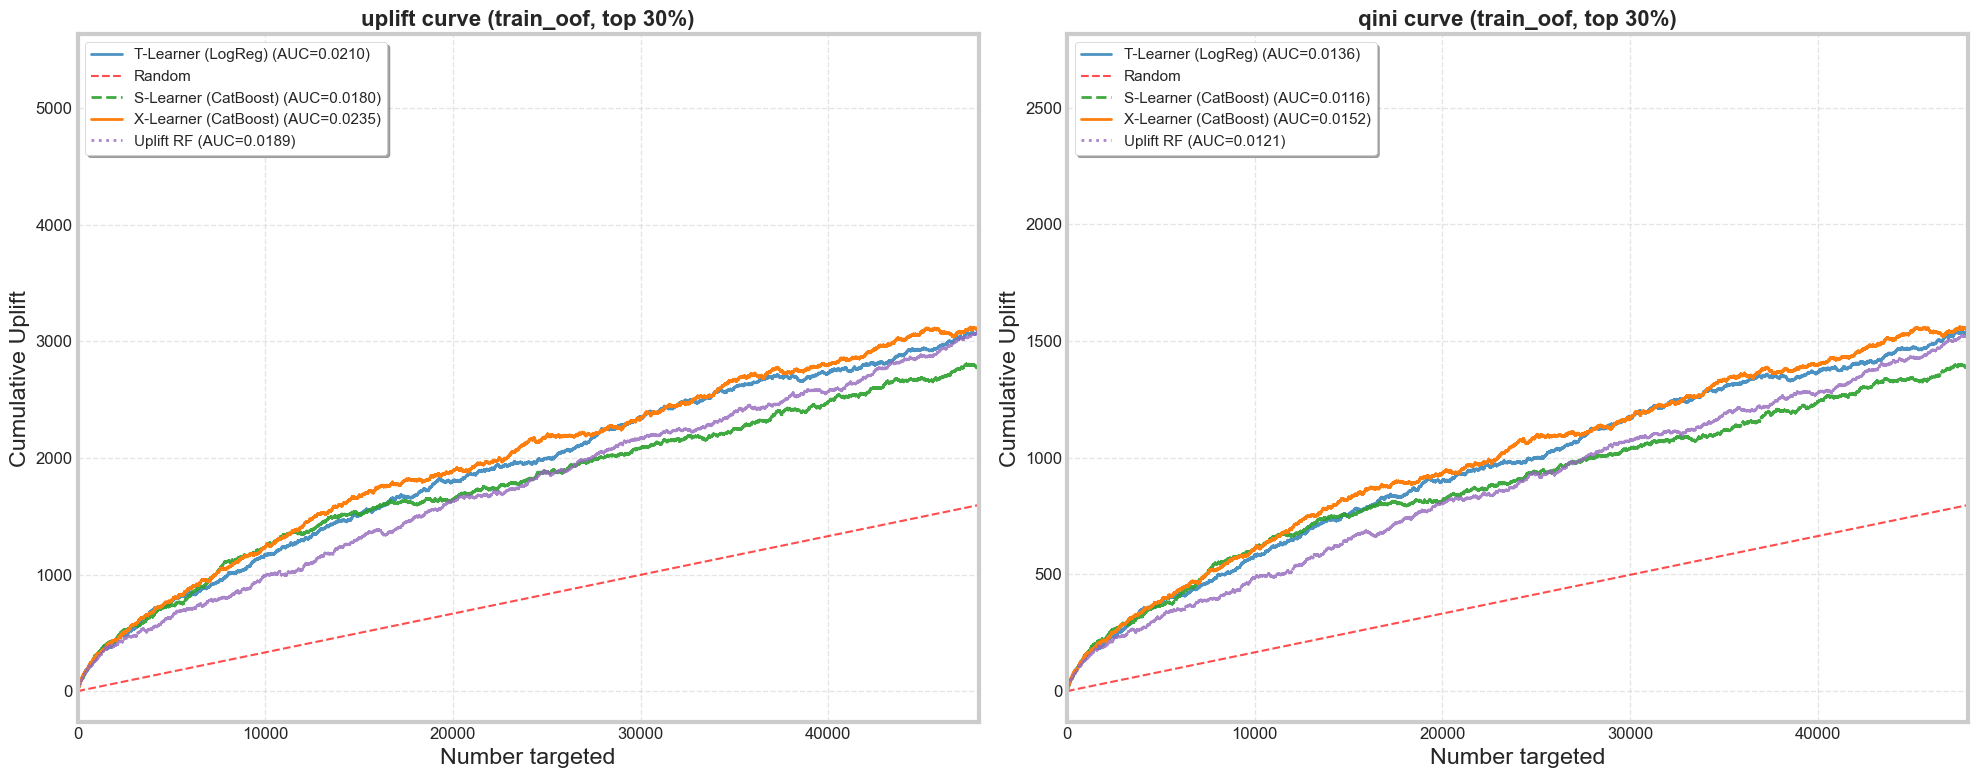

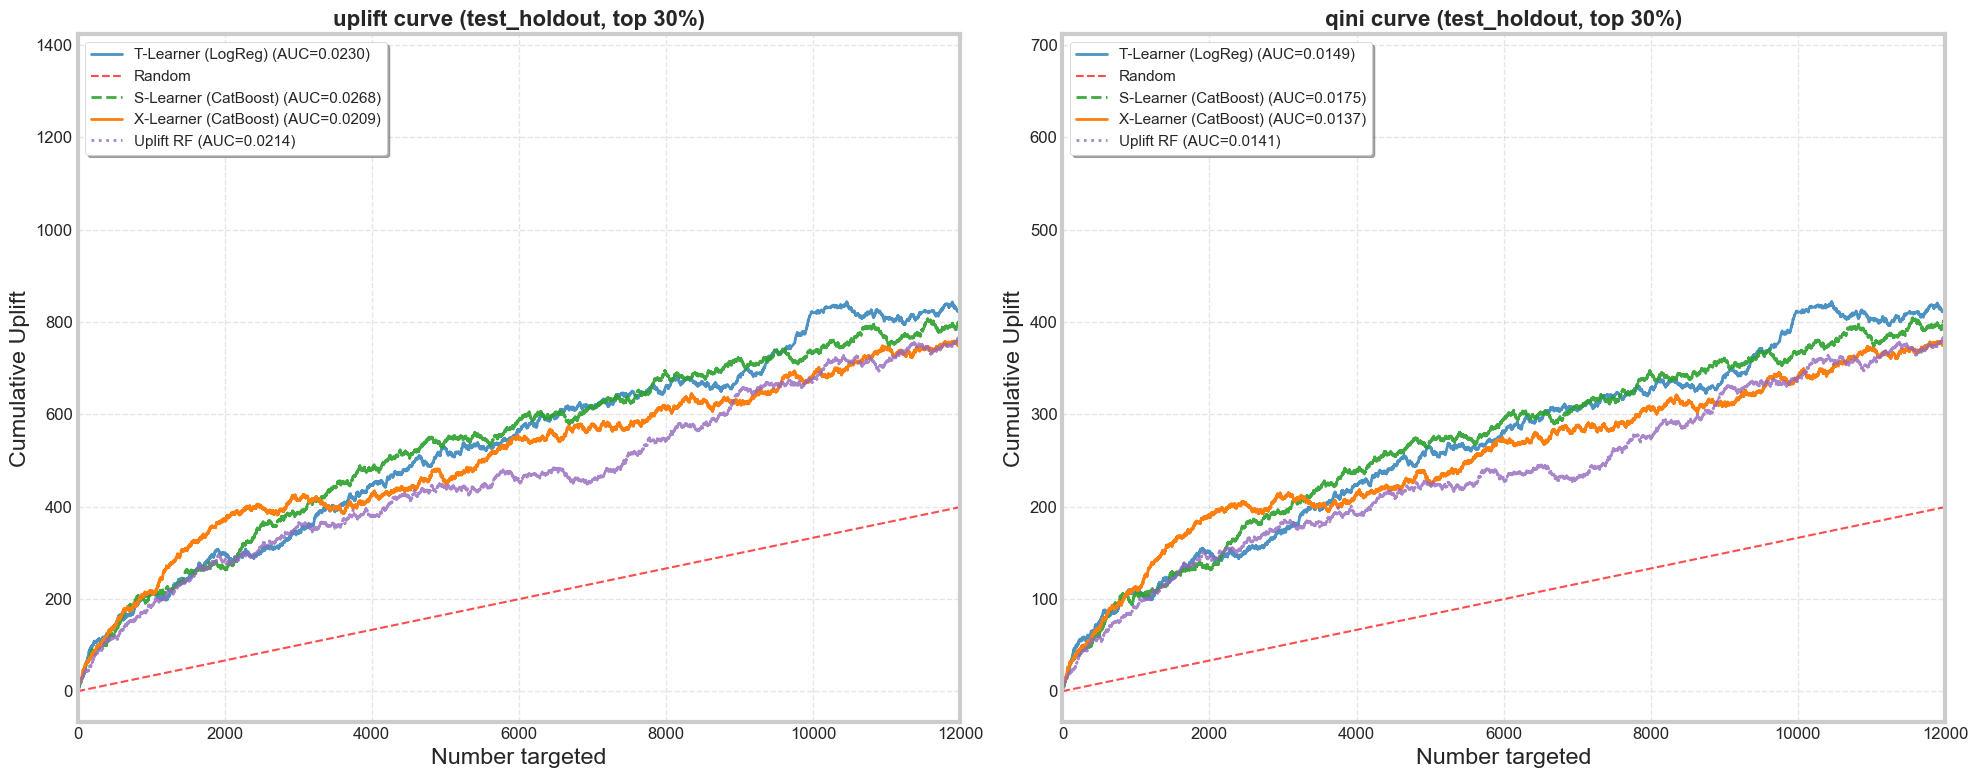

In [16]:
top_k_percent = 0.3

model_colors = {
    "T-Learner (LogReg)": "#1f77b4",
    "S-Learner (CatBoost)": "#2ca02c",
    "X-Learner (CatBoost)": "#ff7f0e",
    "Uplift RF": "#9467bd"
}

model_styles = {
    "T-Learner (LogReg)": {"ls": "-", "alpha": 0.8},
    "S-Learner (CatBoost)": {"ls": "--", "alpha": 0.9},
    "X-Learner (CatBoost)": {"ls": "-", "alpha": 1.0},
    "Uplift RF": {"ls": ":", "alpha": 0.8}
}

split_specs = {
    "train_oof": {
        "y": y_train_full,
        "t": t_train_full,
        "preds_dict": oof_train_preds
    },
    "test_holdout": {
        "y": y_test_holdout,
        "t": t_test_holdout,
        "preds_dict": test_holdout_preds
    }
}

for split_name, split_data in split_specs.items():
    y_split = split_data["y"]
    t_split = split_data["t"]
    preds_dict = split_data["preds_dict"]

    max_x = int(len(y_split) * top_k_percent)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    for model_name, preds in preds_dict.items():
        style = model_styles.get(model_name, {"ls": "-", "alpha": 0.8})
        color = model_colors.get(model_name, "gray")

        plot_uplift_curve(
            y_split,
            preds,
            t_split,
            name=model_name,
            ax=axes[0],
            color=color,
            perfect=False,
            **style
        )

        plot_qini_curve(
            y_split,
            preds,
            t_split,
            name=model_name,
            ax=axes[1],
            color=color,
            perfect=False,
            **style
        )

    axes[0].set_title(f"uplift curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')
    axes[1].set_title(f"qini curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')

    for ax in axes:
        ax.set_xlim(0, max_x)
        ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
        ax.grid(True, which='both', linestyle='--', alpha=0.5)
        ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout()
    plt.show()

### Почему X-Learner показывает более состоятельный результат?

Ранее **T-Learner (LogReg)** показывал небольшое преимущество за счет устойчивости к шуму. Однако в текущем пайплайне по **средним CV / OOF-метрикам** лидером стал **X-Learner**:

1. **Эффект калибровки.** X-Learner - это мета-алгоритм, который восстанавливает индивидуальный эффект через промежуточные псевдо-таргеты. Без калибровки такие оценки обычно шумные. После калибровки вероятностей X-Learner стал точнее ранжировать клиентов именно по инкрементальному эффекту.
2. **Синергия CatBoost и кластерных фич.** Новые признаки и кластерные представления имеют нелинейную структуру. CatBoost внутри X-Learner лучше использует эту нелинейность, чем более простой T-Learner на логистической регрессии.
3. **Лучшее качество ранжирования по CV.** По средним метрикам на train OOF X-Learner показал лучшие **AUUC, Qini, Uplift@10%, Uplift@30% и Uplift@50%**, то есть в среднем по фолдам он лучше концентрирует самых убеждаемых клиентов вверху списка.

При этом на **отдельном holdout** результаты оказались менее однозначными: там X-Learner уже не лидирует по AUUC/Qini и уступает T-learner. Тем не менее, поскольку основная задача uplift-модели - **стабильно ранжировать клиентов по инкрементальному эффекту**, а не выиграть один конкретный holdout по всем метрикам, в качестве основной модели все равно разумнее брать **X-Learner**, но с оговоркой о меньшей стабильности на внешнем тесте. Далее X-learner покажет большую эффективность при рассмотрении ненакопительного uplift (спойлер).

При этом добавленный к сравнению **Uplift RF** выглядит неплохо на части метрик и в середине выборки, но хуже концентрирует максимальный uplift в самом верху ранжирования. Для данной задачи это менее актуально, чем у X-Learner и T-learner.

### Ключевые инсайты

* **По средним CV-метрикам лидирует X-Learner.** Он лучший по **AUUC (0.0236), Qini (0.0152), Uplift@10% (0.1087), Uplift@30% (0.0653) и Uplift@50% (0.0516)**.
* **Holdout показывает, что разрыв между моделями невелик.** Это говорит о том, что выбор модели не абсолютен и требует дополнительношго анализа способности моделей к разбиению сегментов клиентов.
* **X-Learner лучше ранжирует верх базы.** Он сильнее концентрирует uplift в верхних бакетах, а это особенно важно для реального таргетинга при ограниченном бюджете коммуникаций.

Теперь посмотрим на uplift по перцентилям (некумулятивный):

In [22]:
percentile_frames = []

for model_name, preds in oof_train_preds.items():
    df_train_pct = uplift_by_percentile(
        y_true=y_train_full,
        uplift=preds,
        treatment=t_train_full,
        strategy='overall',
        bins=10,
        std=False,
        total=False,
        string_percentiles=True
    ).reset_index().rename(columns={'index': 'percentile'})

    df_train_pct['Model'] = model_name
    df_train_pct['Split'] = 'train_oof'
    percentile_frames.append(df_train_pct)

for model_name, preds in test_holdout_preds.items():
    df_test_pct = uplift_by_percentile(
        y_true=y_test_holdout,
        uplift=preds,
        treatment=t_test_holdout,
        strategy='overall',
        bins=10,
        std=False,
        total=False,
        string_percentiles=True
    ).reset_index().rename(columns={'index': 'percentile'})

    df_test_pct['Model'] = model_name
    df_test_pct['Split'] = 'test_holdout'
    percentile_frames.append(df_test_pct)

all_percentiles_df = pd.concat(percentile_frames, ignore_index=True)

for col in ['n_treatment', 'n_control']:
    all_percentiles_df[col] = all_percentiles_df[col].round().astype('Int64')

all_percentiles_df['n_total'] = all_percentiles_df['n_treatment'] + all_percentiles_df['n_control']

In [23]:
for split_name in ['train_oof', 'test_holdout']:
    print(split_name)
    
    split_percentiles_df = all_percentiles_df[all_percentiles_df['Split'] == split_name].copy()

    pivot_uplift = split_percentiles_df.pivot(index='percentile', columns='Model', values='uplift').reset_index()
    pivot_n_treat = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_treatment').reset_index()
    pivot_n_ctrl = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_control').reset_index()
    pivot_n_total = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_total').reset_index()

    display_df = pivot_uplift.copy()
    display_df = display_df.rename(columns={'percentile': 'Перцентиль (бакет)'})
    model_columns = [col for col in display_df.columns if col != 'Перцентиль (бакет)']

    for model in model_columns:
        display_df[model] = (
            pivot_uplift[model].apply(lambda x: f'{x:+.2%}' if pd.notna(x) else 'nan')
            + '\n' +
            'n=' + pivot_n_total[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
            + ', t=' + pivot_n_treat[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
            + ', c=' + pivot_n_ctrl[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
        )

    gmap_df = pivot_uplift[model_columns].copy()
    gmap_df.index = display_df.index

    styled_df = (
        display_df.style
        .background_gradient(
            cmap='RdYlGn',
            subset=model_columns,
            gmap=gmap_df,
            vmin=-0.05,
            vmax=0.05,
            axis=None
        )
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black',
            'white-space': 'pre-line'
        })
        .set_table_styles([
            {
                'selector': 'th',
                'props': [
                    ('text-align', 'center'),
                    ('background-color', '#ff7f0e'),
                    ('border', '1px solid black')
                ]
            }
        ])
        .hide(axis='index')
    )

    display(styled_df)

train_oof


Перцентиль (бакет),S-Learner (CatBoost),T-Learner (LogReg),Uplift RF,X-Learner (CatBoost)
0-10,"+9.92% n=16004, t=7919, c=8085","+9.80% n=16004, t=8034, c=7970","+8.65% n=16004, t=7921, c=8083","+10.92% n=16004, t=7932, c=8072"
10-20,"+3.56% n=16003, t=8033, c=7970","+5.56% n=16003, t=7989, c=8014","+5.29% n=16003, t=7946, c=8057","+4.31% n=16003, t=8095, c=7908"
20-30,"+3.81% n=16003, t=8030, c=7973","+3.92% n=16003, t=8024, c=7979","+5.11% n=16003, t=7994, c=8009","+4.25% n=16003, t=7993, c=8010"
30-40,"+2.88% n=16003, t=7979, c=8024","+2.83% n=16003, t=7957, c=8046","+3.58% n=16003, t=8025, c=7978","+3.62% n=16003, t=7943, c=8060"
40-50,"+1.90% n=16003, t=8029, c=7974","+2.23% n=16003, t=7930, c=8073","+1.29% n=16003, t=8004, c=7999","+2.83% n=16003, t=8028, c=7975"
50-60,"+3.22% n=16003, t=8005, c=7998","+2.23% n=16003, t=8076, c=7927","+1.28% n=16003, t=8097, c=7906","+1.71% n=16003, t=7940, c=8063"
60-70,"+2.98% n=16003, t=7969, c=8034","+1.85% n=16003, t=8027, c=7976","+1.52% n=16003, t=8035, c=7968","+1.34% n=16003, t=8030, c=7973"
70-80,"+1.85% n=16003, t=8034, c=7969","+1.55% n=16003, t=7925, c=8078","+1.90% n=16003, t=7975, c=8028","+0.97% n=16003, t=8004, c=7999"
80-90,"+1.12% n=16003, t=8004, c=7999","+1.62% n=16003, t=7992, c=8011","+2.02% n=16003, t=8043, c=7960","+2.06% n=16003, t=8048, c=7955"
90-100,"+1.85% n=16003, t=7983, c=8020","+1.79% n=16003, t=8031, c=7972","+2.10% n=16003, t=7945, c=8058","+1.03% n=16003, t=7972, c=8031"


test_holdout


Перцентиль (бакет),S-Learner (CatBoost),T-Learner (LogReg),Uplift RF,X-Learner (CatBoost)
0-10,"+12.09% n=4001, t=1981, c=2020","+11.22% n=4001, t=2001, c=2000","+9.47% n=4001, t=2015, c=1986","+10.67% n=4001, t=2011, c=1990"
10-20,"+5.05% n=4001, t=2017, c=1984","+5.35% n=4001, t=1982, c=2019","+3.88% n=4001, t=2035, c=1966","+4.64% n=4001, t=1976, c=2025"
20-30,"+2.69% n=4001, t=2007, c=1994","+4.10% n=4001, t=2012, c=1989","+6.15% n=4001, t=1960, c=2041","+3.60% n=4001, t=2006, c=1995"
30-40,"+4.99% n=4001, t=1987, c=2014","+3.60% n=4001, t=2012, c=1989","+3.19% n=4001, t=2019, c=1982","+1.44% n=4001, t=2027, c=1974"
40-50,"+1.87% n=4001, t=2043, c=1958","-0.78% n=4001, t=2005, c=1996","+3.42% n=4001, t=2064, c=1937","+1.86% n=4001, t=2038, c=1963"
50-60,"+1.99% n=4001, t=1959, c=2042","+2.20% n=4001, t=2002, c=1999","-0.84% n=4001, t=1969, c=2032","+3.49% n=4001, t=2011, c=1990"
60-70,"-1.17% n=4001, t=2039, c=1962","+2.34% n=4001, t=1985, c=2016","+1.84% n=4001, t=2033, c=1968","+3.20% n=4001, t=1983, c=2018"
70-80,"+2.80% n=4001, t=2054, c=1947","+1.91% n=4001, t=1990, c=2011","+4.34% n=4001, t=2022, c=1979","+2.30% n=4001, t=2007, c=1994"
80-90,"+1.66% n=4000, t=1976, c=2024","+3.00% n=4000, t=2018, c=1982","+2.28% n=4000, t=1927, c=2073","+1.28% n=4000, t=2019, c=1981"
90-100,"+1.43% n=4000, t=1933, c=2067","+0.29% n=4000, t=1989, c=2011","+0.86% n=4000, t=1952, c=2048","+1.29% n=4000, t=1918, c=2082"


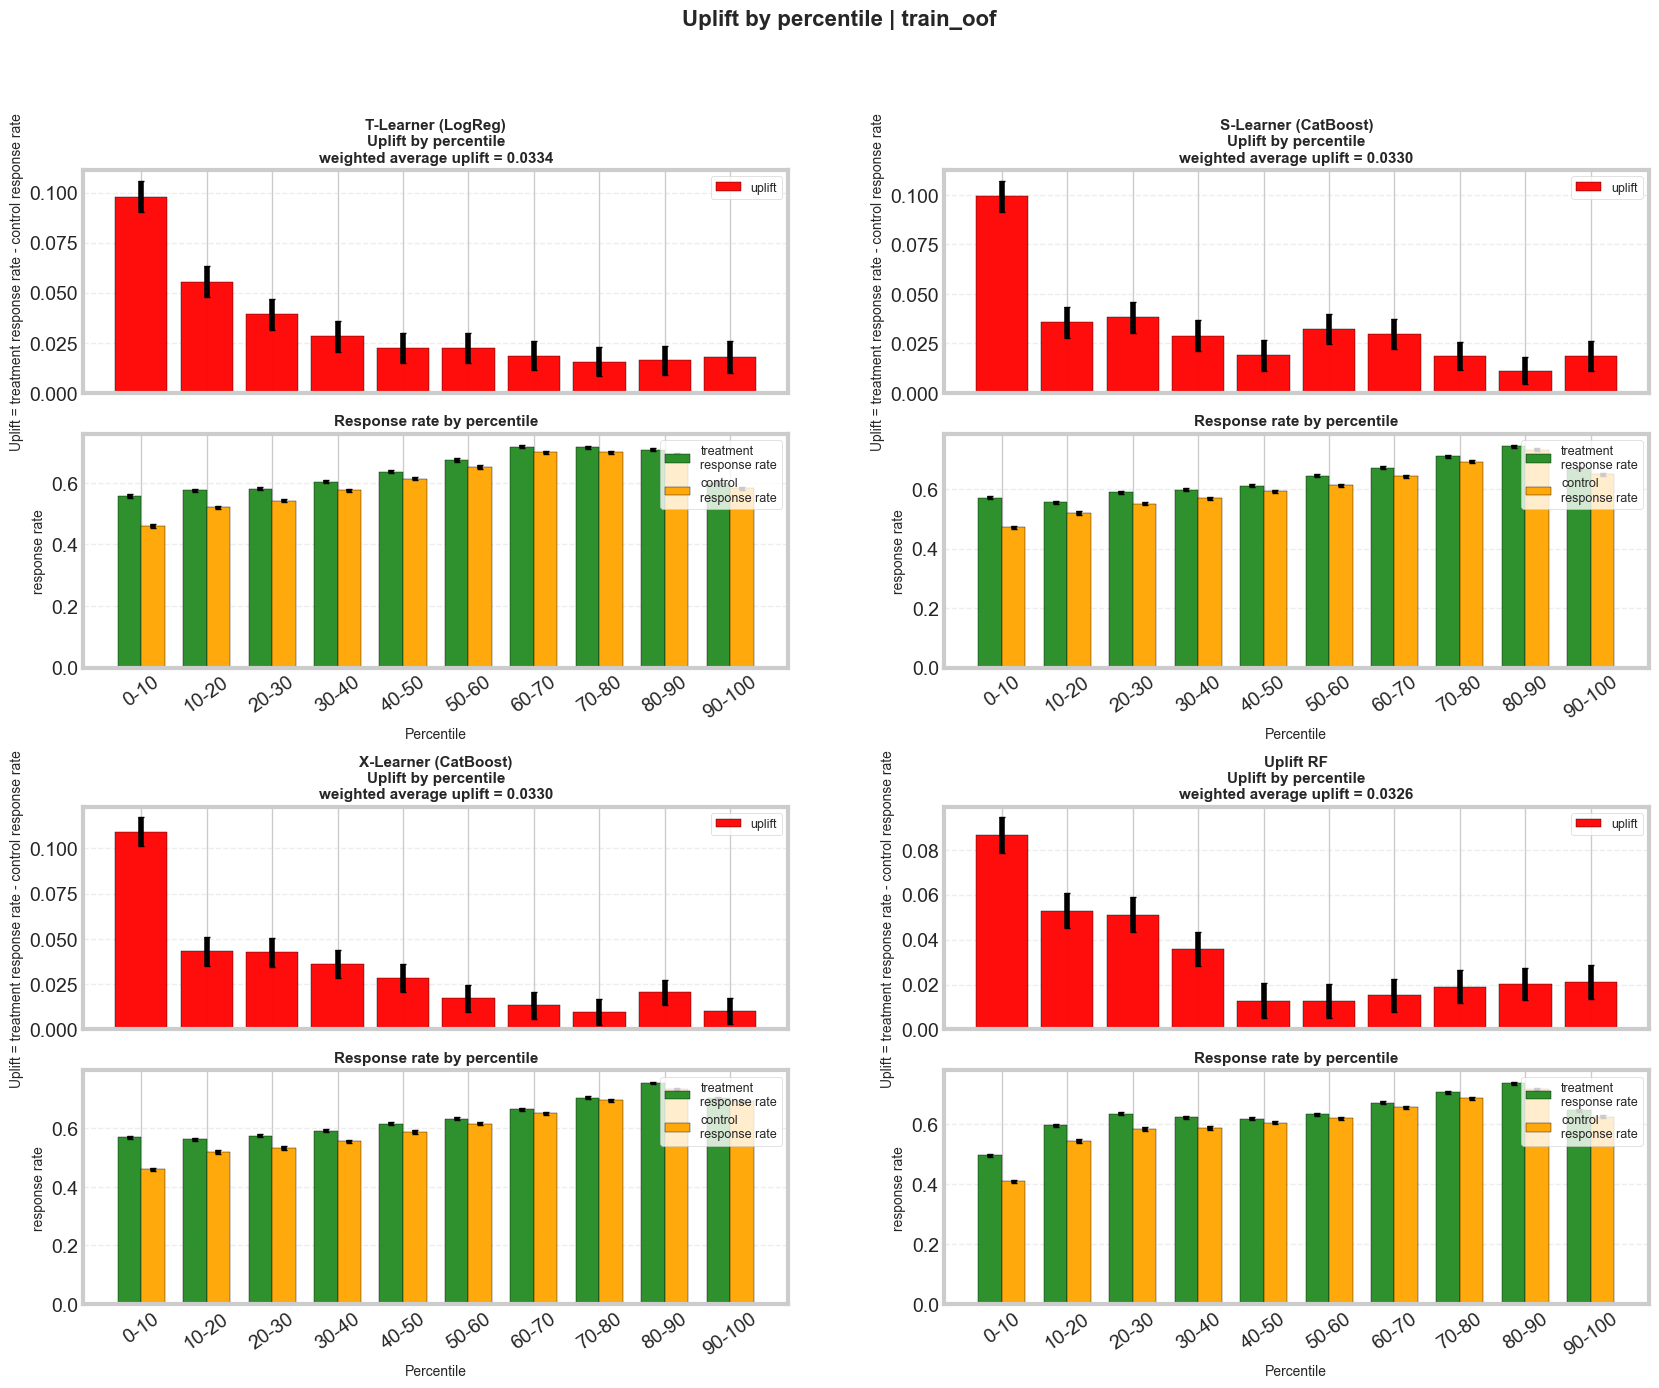

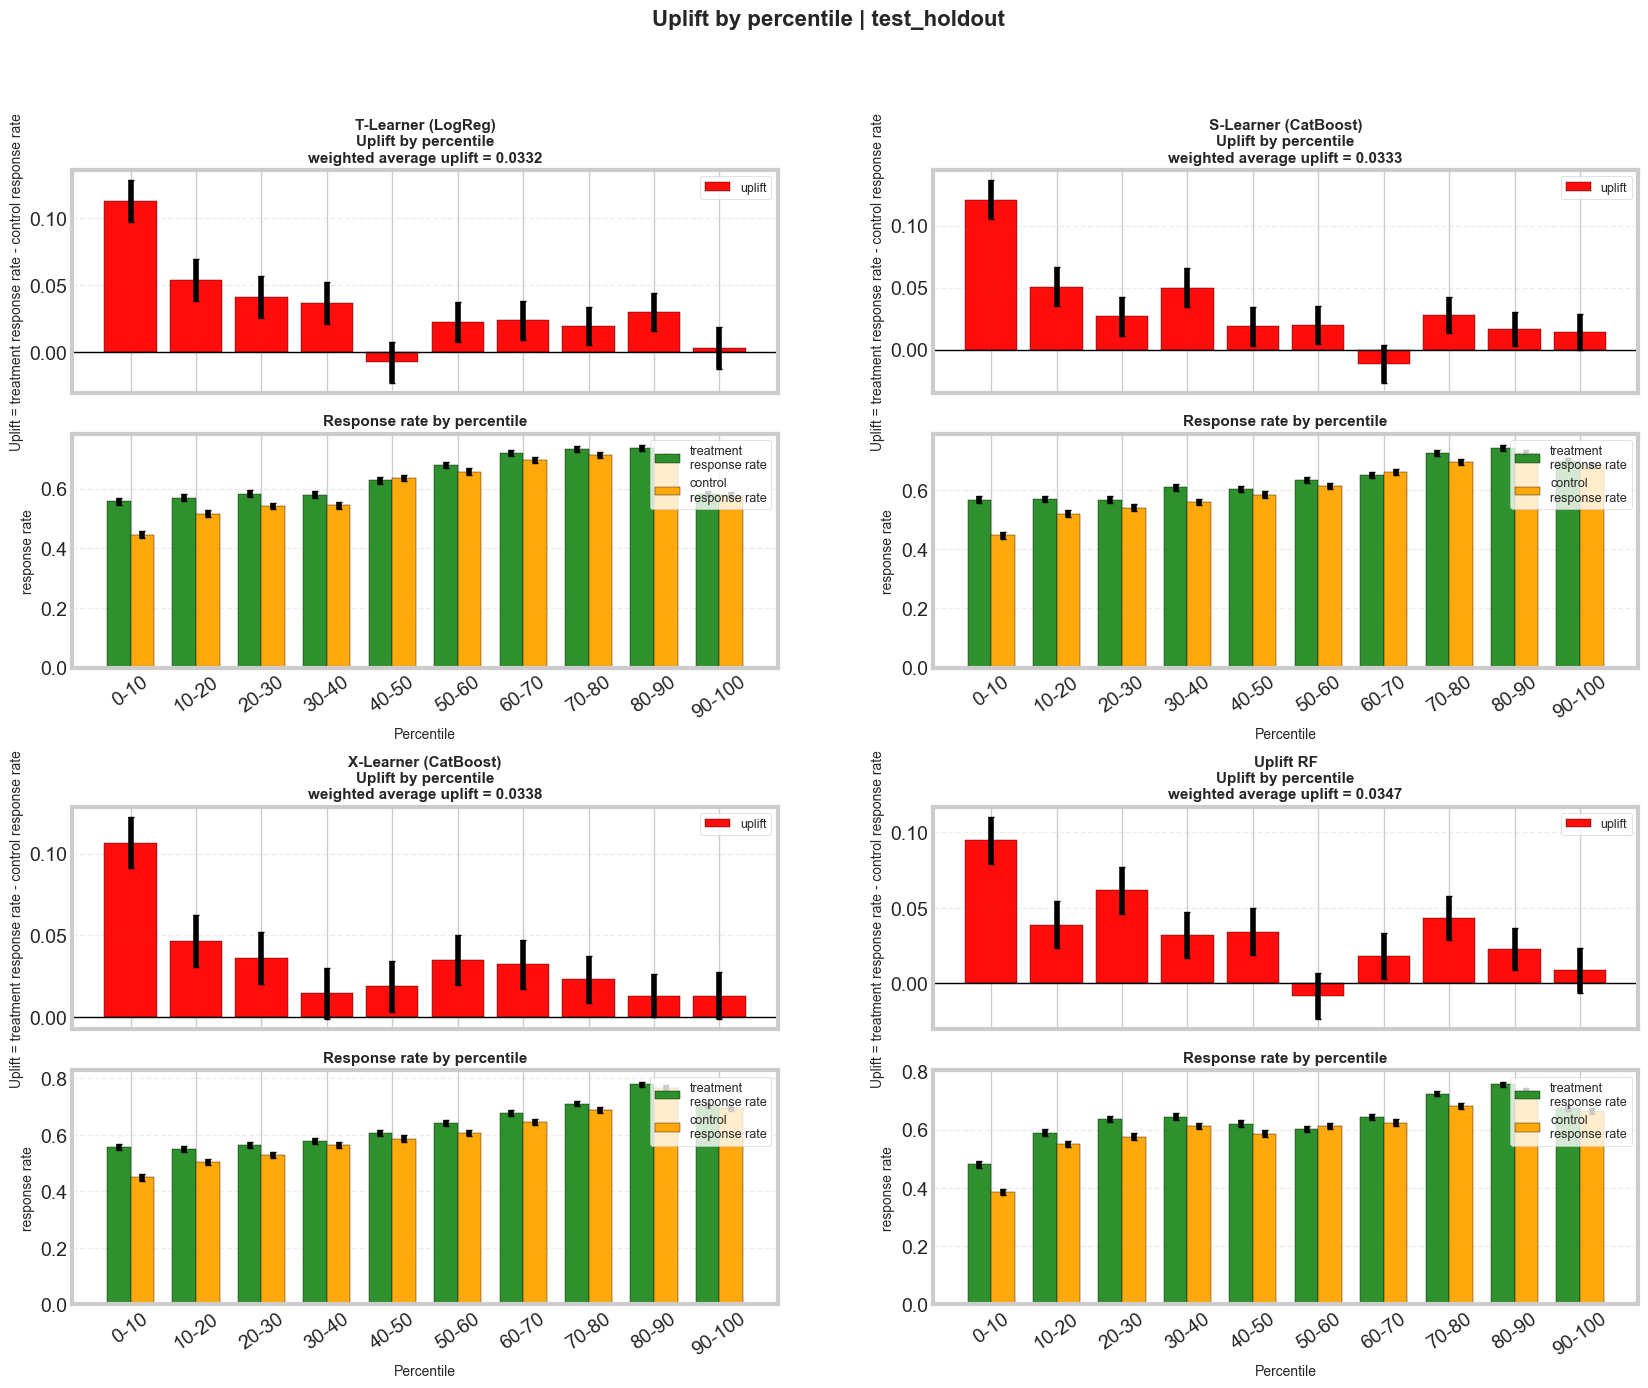

In [29]:
plot_percentile_grid(
    preds_dict=oof_train_preds,
    y_true=y_train_full,
    treatment=t_train_full,
    split_name='train_oof',
    bins=10
)

plot_percentile_grid(
    preds_dict=test_holdout_preds,
    y_true=y_test_holdout,
    treatment=t_test_holdout,
    split_name='test_holdout',
    bins=10
)

Обычная ML-модель ищет склонность к покупке. Она находит наиболее склонных к покупке клиентов, которые купят товар в любом случае.      

На основе анализа фактического некумулятивного uplift по децилям мы оцениваем способность моделей находить сегмент убеждаемых клиентов - тех, чье решение о покупке напрямую зависит от факта коммуникации. 

По **train_oof** X-Learner здесь выглядит лучшей моделью: у него лучший первый бакет (**+10.92%**) и в целом сильный профиль в верхней части ранжирования. Именно это наиболее важно с точки зрения поиска оптимальной стратегии коммуникации: модель должна не просто давать положительный uplift, а поднимать самых чувствительных клиентов наверх.      

При этом **T-Learner** и **Uplift RF** местами выглядят сильнее в середине бакетов: например, у T-Learner лучше бакет 10–20, а у Uplift RF - 20–30. Это значит, что они неплохо ловят более широкий слой клиентов с умеренным эффектом, но слабее концентрируют именно самый ценный топ-сегмент. Для практической стратегии при ограниченном бюджете важнее всего качество сортировки верхней части базы, и по этому критерию X-Learner остается предпочтительным.

На **test_holdout** в верхнем бакете лучшим оказался **S-Learner**, а в отдельных средних бакетах сильнее выглядят **T-Learner** и **Uplift RF**. Тем не менее X-Learner сохраняет важное преимущество: его uplift-профиль на holdout остается **ровным и положительным по всем бакетам**, тогда как у остальных моделей уже появляются локальные отрицательные участки. Это означает, что X-Learner на тесте оказался менее агрессивным, но более стабильным с точки зрения ранжирования без явных провалов.

При этом графики **response rate treatment / control** по перцентилям на выборке в целом растут. Модели сортируют клиентов не по абсолютной вероятности покупки, а по **uplift**, то есть по разнице между treatment и control. Поэтому в верхних бакетах оказываются не обязательно самые горячие клиенты, а самые **убеждаемые**. В нижних бакетах могут лежать клиенты с более высокой базовой вероятностью покупки, поэтому и treatment response rate, и control response rate растут, но разница между ними уменьшается. Т.о., внизу оказываются клиенты, которые и так склонны покупать, а не те, кого сильнее всего меняет коммуникация.

### Выводы по метрике:

**1. Лидеры сегментации (максимальный ROI):**       
Наилучшую способность находить самых отзывчивых клиентов по совокупности CV-метрик и верхним бакетам показали **X-Learner** и **T-Learner**. На train_oof X-Learner показывает максимальный инкрементальный эффект в верхнем дециле (**+10.92%**), а на holdout остается наиболее ровной моделью без отрицательных бакетов.

**2. Экономика кампании (точка отсечения):**            
Наиболее сильный эффект у всех моделей сосредоточен в верхних **20–30%** базы. После 30-го перцентиля uplift заметно снижается, а на holdout у части моделей появляются даже отрицательные значения. Это значит, что с точки зрения PnL разумно ограничивать коммуникацию сегментом **топ-20/30%** клиентов.

**3. Стабильность эффекта:**          
На holdout у **S-Learner**, **T-Learner** и **Uplift RF** есть отдельные бакеты с отрицательным uplift. На этом фоне **X-Learner** выглядит наиболее стабильным, так как сохраняет положительный uplift по всем децилям тестовой выборки.

Посмотрим на значимость признаков X-learner'а:

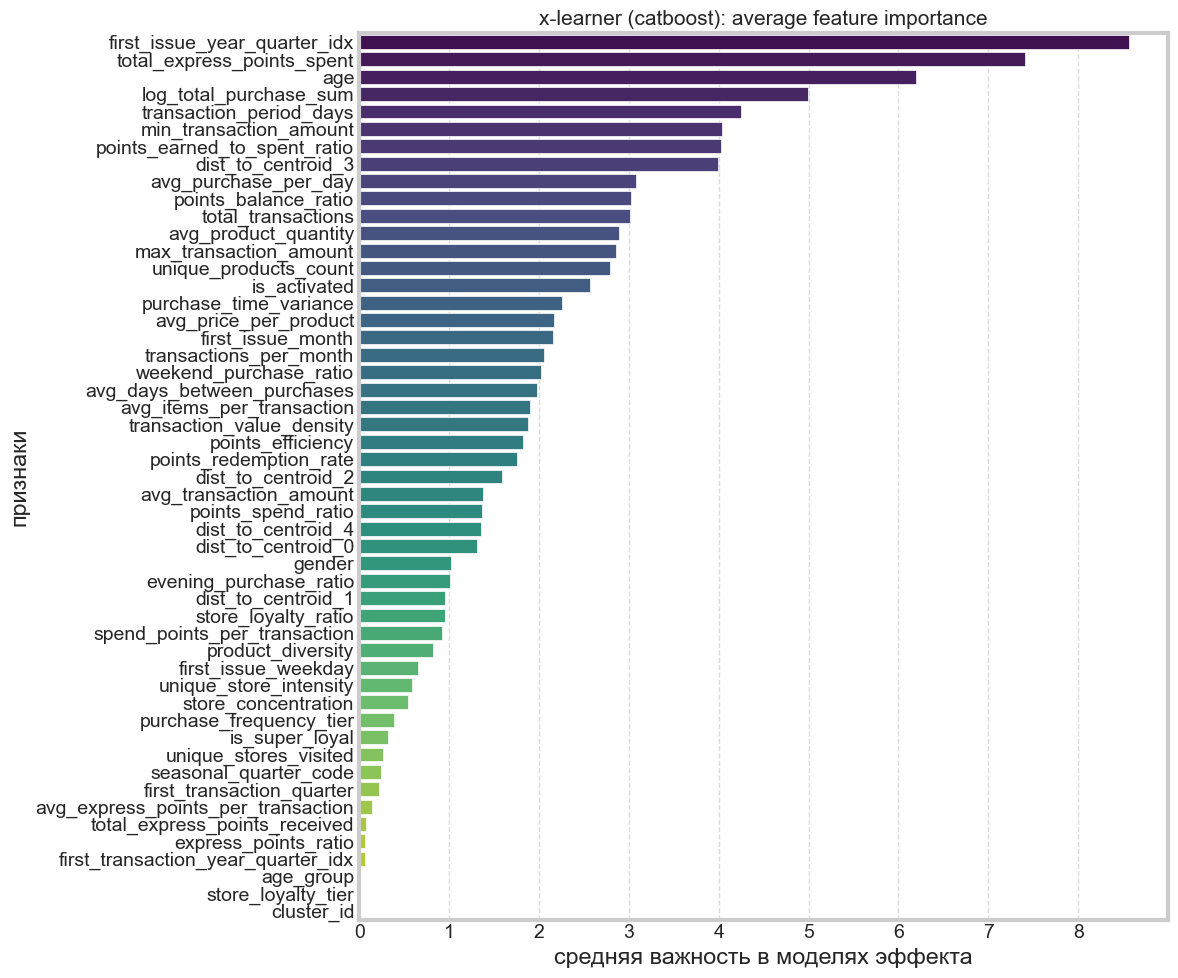

In [24]:
all_features = x_train_full_clust.columns.tolist()

fi0 = x_learner_full.model_tau_0.get_feature_importance()
fi1 = x_learner_full.model_tau_1.get_feature_importance()
avg_importance = (fi0 + fi1) / 2

importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': avg_importance
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(
    x='importance',
    y='feature',
    data=importance_df,
    hue='feature',
    dodge=False,
    palette='viridis',
    legend=False
)

plt.title("x-learner (catboost): average feature importance", fontsize=15)
plt.xlabel("средняя важность в моделях эффекта")
plt.ylabel("признаки")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
cols_to_analyze = [
    c for c in x_train_full.columns
    if pd.api.types.is_numeric_dtype(x_train_full[c]) and c in x_train_full_clust.columns
]

cluster_summary = x_train_full_clust.groupby('cluster_id')[cols_to_analyze].mean()

cluster_sizes = x_train_full_clust['cluster_id'].value_counts().sort_index()
cluster_summary['size'] = cluster_sizes
cluster_summary['size_pct'] = (cluster_summary['size'] / len(x_train_full_clust) * 100).round(1)

base_means = x_train_full_clust[cols_to_analyze].mean()
base_stds = x_train_full_clust[cols_to_analyze].std().replace(0, np.nan)

cluster_z = (cluster_summary[cols_to_analyze] - base_means) / base_stds
cluster_z['size'] = cluster_summary['size']
cluster_z['size_pct'] = cluster_summary['size_pct']

print("Интерпретация кластеров (z-score относительно всей train_full базы):")

display(
    cluster_z
    .sort_values(by='size', ascending=False)
    .style
    .background_gradient(cmap='RdYlGn', axis=0, vmin=-2, vmax=2)
)

Интерпретация кластеров (z-score относительно всей train_full базы):


,first_issue_month,first_issue_weekday,first_issue_year_quarter_idx,total_transactions,avg_transaction_amount,max_transaction_amount,min_transaction_amount,total_express_points_received,total_express_points_spent,avg_express_points_per_transaction,points_earned_to_spent_ratio,unique_products_count,avg_product_quantity,transaction_period_days,first_transaction_year_quarter_idx,unique_stores_visited,store_loyalty_ratio,weekend_purchase_ratio,evening_purchase_ratio,store_concentration,product_diversity,avg_price_per_product,avg_days_between_purchases,express_points_ratio,purchase_time_variance,points_redemption_rate,points_efficiency,avg_purchase_per_day,transactions_per_month,points_spend_ratio,points_balance_ratio,unique_store_intensity,log_total_purchase_sum,seasonal_quarter_code,avg_items_per_transaction,spend_points_per_transaction,transaction_value_density,is_super_loyal,age,is_activated,size,size_pct
cluster_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.101500,-0.003813,-0.217180,0.117086,-0.026927,0.077560,-0.151867,-0.101654,0.054757,-0.073360,-0.105951,0.149367,0.010223,0.374060,-0.420685,0.514636,-0.574749,0.009420,0.008455,-0.574749,-0.019595,0.000160,-0.073641,-0.114812,0.129574,0.037112,-0.075659,-0.098098,-0.122272,0.099714,-0.105951,0.044010,0.196468,0.420685,-0.032336,0.104570,-0.174532,-0.749263,-0.022404,0.310274,81851,51.100000
4,0.149387,-0.017056,-0.066166,0.248612,-0.072530,-0.024564,-0.120083,-0.101682,0.048386,-0.073433,-0.082559,0.171191,-0.035336,0.399082,-0.426370,-0.700866,1.003575,-0.049494,-0.052155,1.003575,-0.231289,-0.058555,-0.099682,-0.115207,-0.072233,0.000540,-0.097135,-0.082628,-0.043146,0.019917,-0.082559,-0.693009,0.242384,0.426370,-0.048862,0.022199,-0.181664,1.314634,0.174638,0.310576,40995,25.600000
2,-0.700512,0.032258,0.776120,-0.675492,0.111635,-0.248857,0.596923,-0.103405,-0.185007,-0.074633,0.062935,-0.681532,0.007876,-2.018289,2.340019,-0.473274,0.242934,0.035107,0.081682,0.242934,0.404647,0.033338,-0.076382,-0.116243,-0.268800,-0.075673,0.291525,0.558290,0.673776,-0.198418,0.062935,0.893508,-0.947451,-2.340019,0.115014,-0.226001,0.983215,0.298676,-0.220576,-0.516125,24438,15.300000
3,0.270678,0.036261,0.270364,-0.497427,0.248666,0.025491,0.335214,-0.098966,-0.366711,-0.071297,1.024538,-0.403798,0.047354,0.074968,-0.411975,-0.255829,0.006915,0.023107,-0.048926,0.006915,0.222629,0.166498,1.297887,-0.112811,-0.135737,-0.122164,0.025943,-0.225749,-0.515913,-0.425712,1.024538,0.419336,-0.452412,0.411975,0.184161,-0.407682,-0.179165,0.029815,-0.017928,-2.629981,10013,6.300000
0,-0.008473,-0.051256,-0.433473,0.626533,-0.014877,0.177393,-0.216106,5.854761,0.631877,4.225593,0.095098,0.532089,-0.020056,0.583308,-0.419820,0.269214,-0.037964,0.061691,-0.022029,-0.037964,-0.377620,-0.034573,-0.371271,6.616946,0.103685,0.004654,1.020771,0.012324,0.174447,0.048789,0.095098,-0.448695,0.609406,0.419820,-0.001776,0.049703,-0.183194,-0.059654,0.089423,0.299486,2734,1.700000


### 1. Группировка признаков по влиянию на uplift

* **Жизненный цикл клиента (лидер: `first_issue_year_quarter_idx`)**  
    Самый сильный сигнал в модели. X-Learner явно опирается на стаж клиента. Признаки возраста лояльности клиента значимее, чем просто календарная сезонность или отдельный месяц подключения.

* **Механика баллов (лидер: `total_express_points_spent`)**  
    Особенно важны фактические траты баллов, а также связанные с ними коэффициенты: `points_earned_to_spent_ratio`, `points_balance_ratio`, `points_efficiency`. Это означает, что модель выделяет клиентов, для которых коммуникация наиболее эффективно дожимает уже существующую вовлеченность в бонусную механику.

* **Объем и интенсивность покупок (`log_total_purchase_sum`, `transaction_period_days`, `avg_purchase_per_day`, `total_transactions`)**  
    Важен не один конкретный показатель, а сочетание масштаба покупок, длины истории и плотности активности. Модель ищет тех, у кого поведение достаточно насыщенное, чтобы коммуникация могла изменить решение о покупке.

* **Порог и чувствительность к чеку (`min_transaction_amount`, `avg_transaction_amount`)**  
    Высокая важность `min_transaction_amount` и средних чековых признаков говорит о том, что X-Learner различает клиентов по нижнему порогу входа в покупку: у части клиентов дополнительный стимул может работать как способ подтолкнуть к небольшой или средней покупке.

* **Геометрия данных (лидер: `dist_to_centroid_3`)**  
    Из кластерных признаков в топ попали именно **расстояния до центроидов**, прежде всего `dist_to_centroid_3`, а затем `dist_to_centroid_2`, `dist_to_centroid_4`, `dist_to_centroid_0`, `dist_to_centroid_1`. Т.о. кластеризация действительно нашла скрытую структуру клиентских паттернов. При этом сам `cluster_id` практически не важен - модели полезнее **мягкая близость к сегментам**, чем жесткая принадлежность к одному кластеру.

* **Возраст (`age`)**  
    В текущей версии возраст оказался одним из самых сильных индивидуальных признаков. Значит, uplift действительно различается не только по транзакционному поведению, но и по более стабильным клиентским характеристикам.

### 2. Портреты кластеров и их роль в модели

| ID | Тип клиента | Размер | Краткий профиль | Роль в uplift |
| :--- | :--- | :---: | :--- | :--- |
| **1** | **Diversified regulars** | **51.1%** | Самый массовый сегмент. Умеренно активные, с длинной историей, более широким набором магазинов и товаров, но без сильной привязки к одному магазину. | Базовый средний сегмент. Важен как массовая аудитория, но модель использует его скорее как фон относительно более выраженных паттернов. |
| **4** | **Super-loyal veterans** | **25.6%** | Более возрастные и давно пришедшие клиенты с высокой концентрацией покупок в одном магазине: очень высокий `store_loyalty_ratio`, `store_concentration`, `is_super_loyal`. | Стабильный и предсказуемый сегмент. Вероятно, коммуникация здесь работает иначе, чем на широкой базе, поэтому близость к этому кластеру помогает модели корректировать uplift. |
| **2** | **New\intensive customers** | **15.3%** | Относительно новые клиенты с короткой историей (`transaction_period_days` сильно ниже среднего), но высокой плотностью активности внутри этой короткой истории (`avg_purchase_per_day`, `transactions_per_month`, `transaction_value_density` выше среднего). | Важный сегмент быстро разогревающихся клиентов: по ним коммуникация может давать заметный прирост, пока их поведение еще не стабилизировалось. |
| **3** | **Irregular clients** | **6.3%** | Малый сегмент с низкой активацией (`is_activated` резко ниже среднего), редкими покупками (`avg_days_between_purchases` сильно выше среднего) и слабой общей вовлеченностью. | Один из самых важных кластеров для uplift-ранжирования: расстояние до него (`dist_to_centroid_3`) стало главным кластерным признаком, то есть модель явно отделяет таких клиентов от остальных. |
| **0** | **Whales** | **1.7%** | Очень маленький, но яркий сегмент с экстремально высокими значениями по бонусным метрикам: `total_express_points_received`, `avg_express_points_per_transaction`, `express_points_ratio`, а также высоким оборотом. | Нишевый, но ценный сегмент. Коммуникации для таких клиентов, вероятно, завязаны на бонусную механику сильнее, чем на стандартный промо-сигнал. |

### 3. Главные инсайты по кластерам

* **Кластеры 1 и 4 - это две разные стабильные базы.**  
  Первый - широкий, диверсифицированный массовый сегмент; второй - очень лояльные клиенты с высокой концентрацией покупок. Модель различает их, потому что реакция на коммуникацию у этих групп разная.

* **Кластер 2 - это новые, но уже интенсивные клиенты.**  
  У них короткая история, но высокая плотность активности. Здесь uplift может быть особенно чувствителен к таймингу коммуникации.

* **Кластер 3 - самый важный с точки зрения геометрии.**  
  Именно `dist_to_centroid_3` оказался сильнейшим кластерным признаком. Значит, модель явно использует отделение спящих / неактивных клиентов от остальных как важный фактор при оценке инкрементального эффекта.

* **Кластер 0 - редкий бонусный сегмент.**  
  Это не массовая аудитория, но она помогает модели точнее учитывать экстремальные паттерны бонусного поведения.

### 4. Инсайты для DL-моделей

* **Embeddings для временных и loyalty-признаков.**  
  Так как доминируют `first_issue_year_quarter_idx`, возраст и бонусные признаки, в нейросетевой модели логично использовать эмбеддинги для временных категорий и признаков жизненного цикла клиента.

* **Последовательности вместо агрегатов.**  
  Высокая важность `transaction_period_days`, `avg_purchase_per_day`, `avg_days_between_purchases`, бонусных коэффициентов и общего оборота показывает, что необходим переход к последовательностям транзакций, а не только к агрегатам.

* **Мягкая геометрия.**  
  Так как важны расстояния до центроидов, а не сам `cluster_id`, в DL-подходе лучше использовать латентное представление клиента в разрезе сегментов, а не просто категориальный номер кластера.